# Exploring The Guardian's University League Tables
The following code explore the overall ranking and the individual subject-level rankings using data visualizations, correlation metrics, and basic statistical analysis.

## Load Tables
The following code loads the overall table as well as individual tables for each subject area.

In [67]:
from extract_data import load_data

#ranking = load_data()

#main_rank = ranking["main_rank"]
#subjects = ranking["subjects"]
#subject_dataframes = ranking["subject_dataframes"]

In [68]:
import pandas as pd
from pathlib import Path
import pickle

data_dir = Path("data")

# ---------------------------------------------------------------
# Load main rank table
# ---------------------------------------------------------------
main_rank = pd.read_csv(data_dir / "main_rank.csv")

# ---------------------------------------------------------------
# Load subject-level tables (dict of {subject_name: DataFrame})
# ---------------------------------------------------------------
with open(data_dir / "data.pkl", "rb") as f:
    subject_dataframes = pickle.load(f)

print(f"Main rank table: {main_rank.shape[0]} institutions, {main_rank.shape[1]} columns")
print(f"Subject tables loaded: {len(subject_dataframes)}")
print("Subjects:", list(subject_dataframes.keys())[:10], "...")  # preview first 10

Main rank table: 123 institutions, 15 columns
Subject tables loaded: 66
Subjects: ['S250', 'S195', 'S040', 'S150', 'S225', 'S325', 'S450', 'S100', 'S045', 'S240'] ...


In [69]:
# Preview main table
main_rank.head(10)

,institutionId,name,url,rank2026,rank2025,rank2024,guardianScore,percentSatisfiedWithTeaching,expenditurePerStudent,studentStaffRatio,careerProspects,valueAdded,averageEntryTariff,percentSatisfiedWithAssessment,continuation
0,156,Oxford,https://www.theguardian.com/education/2009/may...,1,1.0,2.0,100.0,94.0,10.0,9.1,92,6.3,197,76.0,97.3
1,173,St Andrews,https://www.theguardian.com/education/2009/may...,2,2.0,1.0,98.4,92.8,6.5,11.0,90,5.5,210,81.7,96.8
2,114,Cambridge,https://www.theguardian.com/education/2009/may...,3,3.0,3.0,94.6,93.4,9.4,10.8,92,5.9,210,72.9,98.4
3,137,London School of Economics,https://www.theguardian.com/education/2009/may...,4,4.0,4.0,93.8,89.4,8.7,11.4,93,5.9,185,76.2,96.4
4,116,Durham,https://www.theguardian.com/education/2009/may...,5,6.0,7.0,85.5,90.5,6.4,12.4,89,6.0,180,81.6,96.7
5,132,Imperial College,https://www.theguardian.com/education/2009/may...,6,5.0,5.0,82.9,87.7,8.7,11.7,95,6.1,196,67.3,94.9
6,163,Warwick,https://www.theguardian.com/education/2009/may...,7,8.0,9.0,79.1,90.0,7.7,11.7,89,5.1,171,77.8,95.3
7,109,Bath,https://www.theguardian.com/education/2009/may...,8,7.0,6.0,76.1,88.1,5.9,15.1,90,6.2,171,75.2,96.6
8,24,University of the Arts London,https://www.theguardian.com/education/2009/may...,9,13.0,15.0,73.9,83.1,9.6,9.9,71,6.5,141,84.4,91.0
9,149,UCL,https://www.theguardian.com/education/2009/may...,10,9.0,8.0,73.5,86.9,6.1,10.7,89,6.0,172,75.3,95.9


In [70]:
# List all universities in the main ranking table
all_universities = main_rank["name"].unique()

university_alliance = [
    "Anglia Ruskin",
    "Birmingham City",
    "Bournemouth",
    "Brighton",
    "Coventry",
    "De Montfort",
    "Derby",
    "Glasgow Caledonian",
    "Greenwich",
    "Hertfordshire",
    "Kingston",
    "Leeds Beckett",
    "Middlesex",
    "Oxford Brookes",
    "Robert Gordon",
    "South Wales",
    "Teesside",
    "UWE Bristol",
    "West London",
    "Westminster"
]

# Find all universities in the University Alliance that are present in the main ranking table
ua_universities = [uni for uni in university_alliance if uni in all_universities]

### Save files
To avoid having to reload ranking data, save to files.

In [71]:
#from pathlib import Path
#import pickle

#data_dir = Path("data")
#data_dir.mkdir(exist_ok=True, parents=True)

#output_path = data_dir / "main_rank.csv"
#main_rank.to_csv(output_path, index=False)

#with open(data_dir / "data.pkl", "wb") as f:
#    pickle.dump(subject_dataframes, f)

## Data Exploration
First select only subjects for which Anglia Ruskin is a provider.

In [72]:
subject_dataframes_anglia = {
    subject_id: subject_df
    for subject_id, subject_df in subject_dataframes.items()
    if subject_df["name"].eq("Anglia Ruskin").any()
}

### Plot Correlations
Plot correlations between main score and each metric.

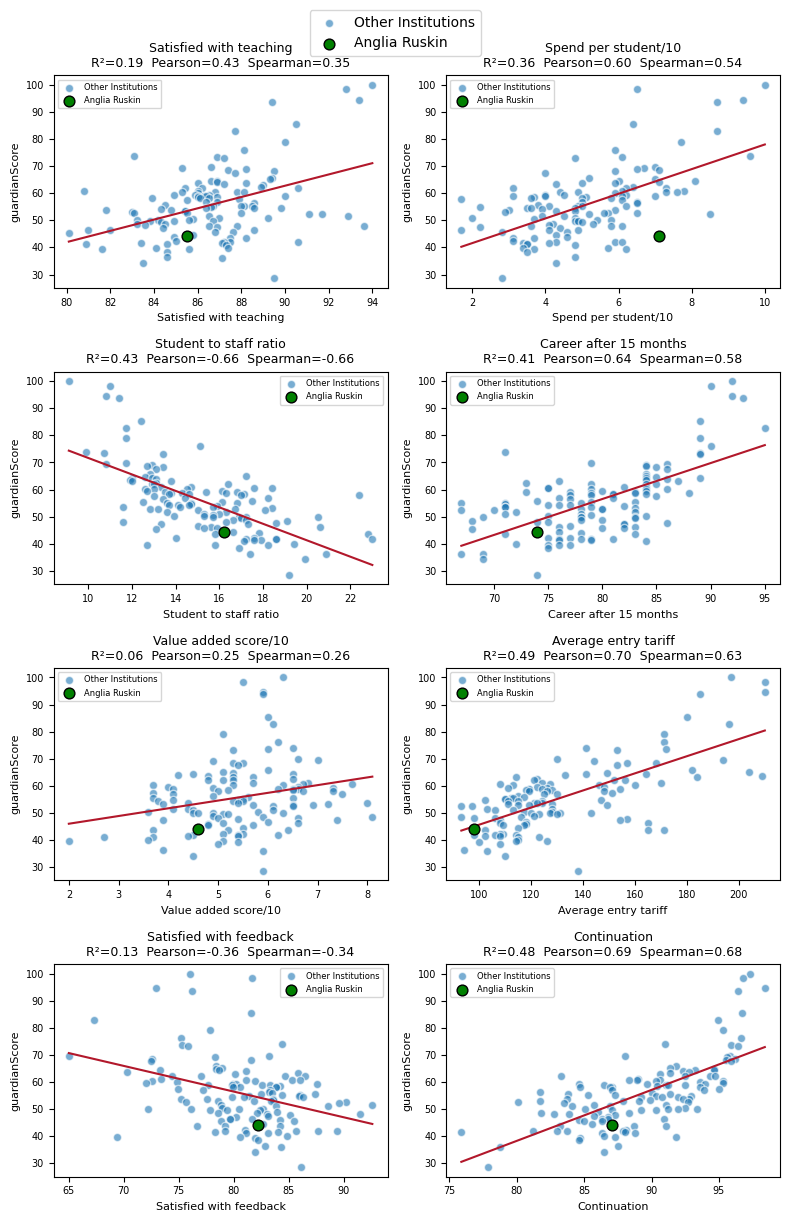

In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# ---------------------------------------------------------------
# Load data
# ---------------------------------------------------------------
df = pd.read_csv("data/main_rank.csv")
TARGET = "guardianScore"
HIGHLIGHT = "Anglia Ruskin"

metrics = main_rank.columns[7:].to_list()

metrics_labels = ["Satisfied with teaching",
                  "Spend per student/10",
                  "Student to staff ratio",
                  "Career after 15 months",
                  "Value added score/10",
                  "Average entry tariff", 
                  "Satisfied with feedback",                 
                  "Continuation"]

# ---------------------------------------------------------------
# Plot
# ---------------------------------------------------------------
fig, axes = plt.subplots(4, 2, figsize=(8, 12))

for ax, col, label in zip(axes.flat, metrics, metrics_labels):
    sub = df[[col, TARGET, "name"]].dropna()
    x, y = sub[col].values, sub[TARGET].values

    # Fit linear regression
    slope, intercept, r_pearson, p_val, se = stats.linregress(x, y)
    r2 = r_pearson ** 2
    r_spearman, _ = stats.spearmanr(x, y)

    # Split highlighted institution from the rest
    is_highlight = sub["name"] == HIGHLIGHT
    rest, hl = sub[~is_highlight], sub[is_highlight]

    # Scatter: rest in blue, highlight in green (on top, larger, outlined)
    ax.scatter(rest[col], rest[TARGET], alpha=0.6, edgecolor="white", s=35, color="tab:blue",
               label="Other Institutions")
    ax.scatter(hl[col], hl[TARGET], color="green", edgecolor="black",
               s=60, zorder=5, label=HIGHLIGHT)

    # Regression line
    xs = np.linspace(x.min(), x.max(), 100)
    ax.plot(xs, slope * xs + intercept, color="#b2182b", linewidth=1.5)

    # Annotate stats
    ax.set_title(
        f"{label}\nR²={r2:.2f}  Pearson={r_pearson:.2f}  Spearman={r_spearman:.2f}",
        fontsize=9
    )
    ax.set_xlabel(label, fontsize=8)
    ax.set_ylabel(TARGET, fontsize=8)
    ax.tick_params(labelsize=7)
    ax.legend(fontsize=6, loc="best")

# Single shared legend for the highlighted institution
handles, labels = axes.flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=1, bbox_to_anchor=(0.5, 1.02))

plt.tight_layout()
plt.show()

C:\Users\md82\AppData\Local\Temp\ipykernel_30048\2464449349.py:31: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  combined = pd.concat(


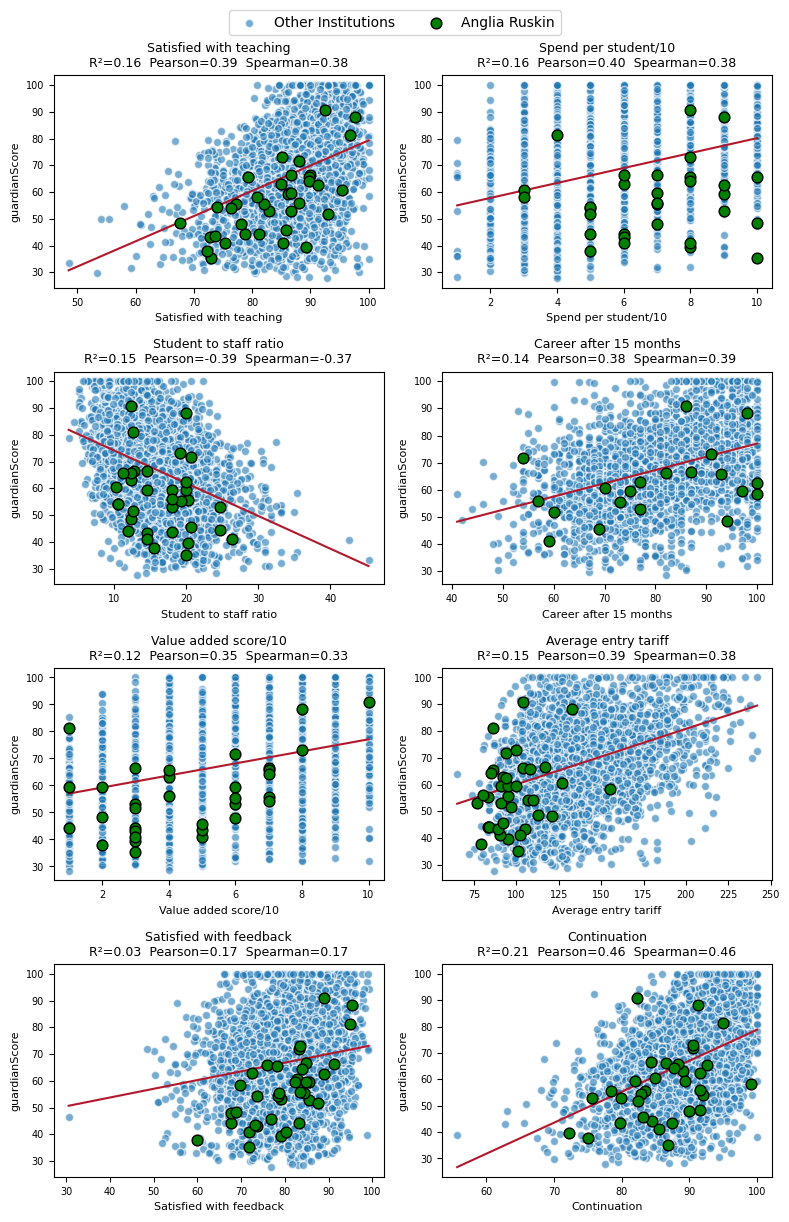

In [74]:
import mplcursors

# ---------------------------------------------------------------
# Load data
# ---------------------------------------------------------------
dfs = subject_dataframes

TARGET = "guardianScore"
HIGHLIGHT = "Anglia Ruskin"

# assumes all dataframes share the same metric columns from index 7 onward
metrics = list(dfs.values())[0].columns[6:14].to_list()

metrics_labels = ["Satisfied with teaching",
                  "Spend per student/10",
                  "Student to staff ratio",
                  "Career after 15 months",
                  "Value added score/10",
                  "Average entry tariff", 
                  "Satisfied with feedback",                 
                  "Continuation"]

# ---------------------------------------------------------------
# Plot
# ---------------------------------------------------------------
fig, axes = plt.subplots(4, 2, figsize=(8, 12))

for ax, col, label in zip(axes.flat, metrics, metrics_labels):

    # Concatenate this metric's data from every dataframe into one pooled sample
    combined = pd.concat(
        [df[[col, TARGET, "name"]].assign(source=df_key) for df_key, df in dfs.items()],
        ignore_index=True
    )
     
    # Force numeric dtypes — guards against stray strings/junk in the CSV
    combined[col] = pd.to_numeric(combined[col], errors="coerce")
    combined[TARGET] = pd.to_numeric(combined[TARGET], errors="coerce")
    combined = combined.dropna(subset=[col, TARGET])

    x, y = combined[col].values, combined[TARGET].values

    # Fit ONE regression line to the pooled data
    slope, intercept, r_pearson, p_val, se = stats.linregress(x, y)
    r2 = r_pearson ** 2
    r_spearman, _ = stats.spearmanr(x, y)

    # Split highlighted institution from the rest (still pooled across sources)
    is_highlight = combined["name"] == HIGHLIGHT
    rest, hl = combined[~is_highlight], combined[is_highlight]

    # Scatter: rest colored by source dataframe
    sc_rest = ax.scatter(rest[col], rest[TARGET], alpha=0.6, edgecolor="white", s=35,
               color="tab:blue", label="Other Institutions")

    # Highlighted institution always in green, on top
    sc_hl = ax.scatter(hl[col], hl[TARGET], color="green", edgecolor="black",
               s=60, zorder=5, label=HIGHLIGHT)

    cursor_hl = mplcursors.cursor(sc_hl, hover=True)

    def make_hl_annot(sel, hl=hl, col=col):
        row = hl.iloc[sel.index]
        sel.annotation.set_text(
            f"{HIGHLIGHT}\nSubject: {row['source']}\n{col}: {row[col]:.2f}\n{TARGET}: {row[TARGET]:.2f}"
    )

    cursor_hl.connect("add", make_hl_annot)

    # Regression line fit to ALL combined data
    xs = np.linspace(x.min(), x.max(), 100)
    ax.plot(xs, slope * xs + intercept, color="#b2182b", linewidth=1.5)

    # Annotate stats (computed on pooled data)
    ax.set_title(
        f"{label}\nR²={r2:.2f}  Pearson={r_pearson:.2f}  Spearman={r_spearman:.2f}",
        fontsize=9
    )
    ax.set_xlabel(label, fontsize=8)
    ax.set_ylabel(TARGET, fontsize=8)
    ax.tick_params(labelsize=7)

# Single shared legend for the highlighted institution and each source dataframe
handles, labels = axes.flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2, bbox_to_anchor=(0.5, 1.02), fontsize=10)

plt.tight_layout()
plt.show()

### Correlation matrices

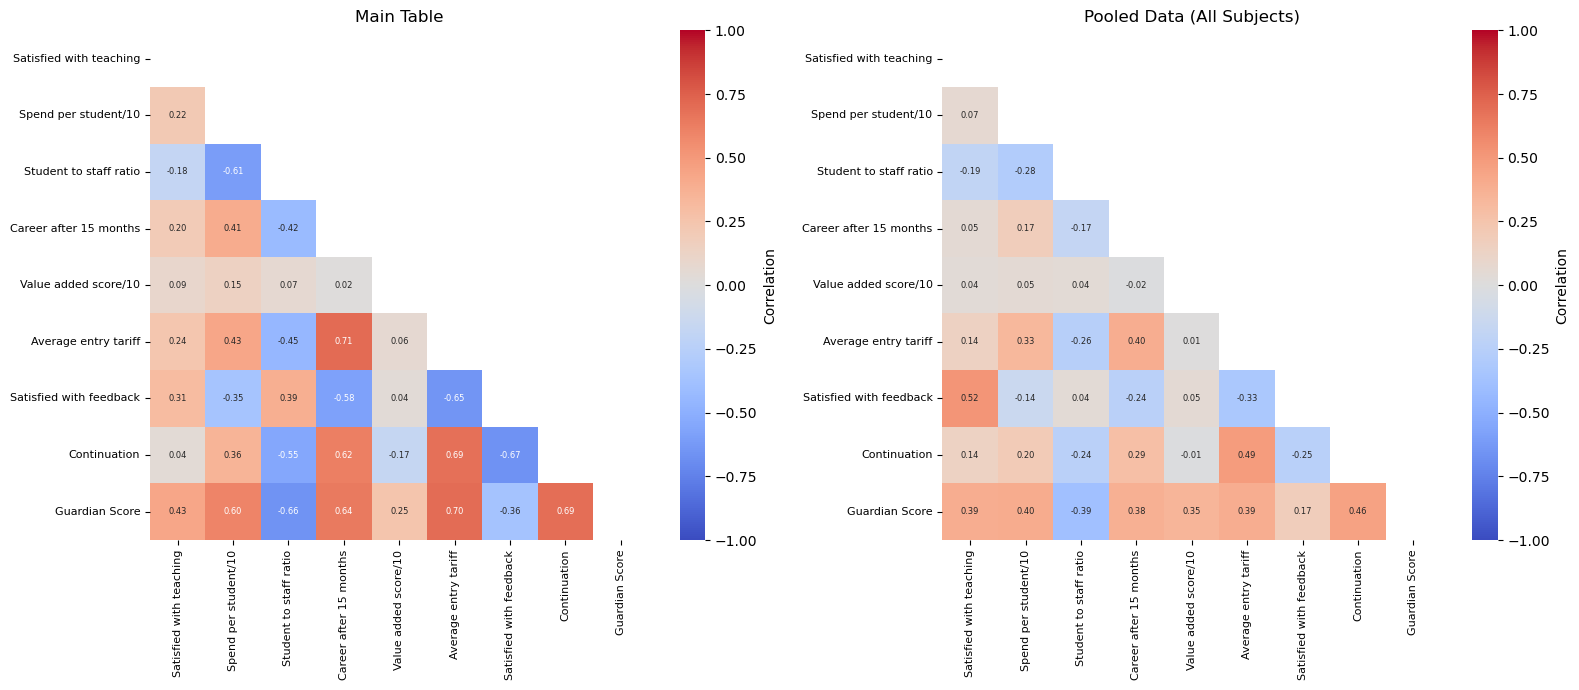

In [20]:
import seaborn as sns

metrics_labels = ["Satisfied with teaching",
                  "Spend per student/10",
                  "Student to staff ratio",
                  "Career after 15 months",
                  "Value added score/10",
                  "Average entry tariff", 
                  "Satisfied with feedback",                 
                  "Continuation"]

cols = list(dfs.values())[0].columns[6:14].to_list() + ["guardianScore"]
cols_main = df.columns[7:].to_list() + ["guardianScore"]
labels = metrics_labels + ["Guardian Score"]

# Main table correlation
main_df = df[cols_main].apply(pd.to_numeric, errors="coerce")
corr_main = main_df.corr()
mask_main = np.triu(np.ones_like(corr_main, dtype=bool))

# Pooled data correlation
dfs_numeric = [d[cols].apply(pd.to_numeric, errors="coerce") for d in dfs.values()]
combined = pd.concat(dfs_numeric, ignore_index=True).dropna(how="all")
corr_pooled = combined.corr()
mask_pooled = np.triu(np.ones_like(corr_pooled, dtype=bool))

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

sns.heatmap(corr_main, mask=mask_main, cmap="coolwarm", vmin=-1, vmax=1,
            annot=True, fmt=".2f", annot_kws={"fontsize": 6},
            xticklabels=labels, yticklabels=labels, cbar_kws={"label": "Correlation"}, ax=axes[0])
axes[0].set_title("Main Table")
axes[0].tick_params(axis="x", rotation=90, labelsize=8)
axes[0].tick_params(axis="y", labelsize=8)

sns.heatmap(corr_pooled, mask=mask_pooled, cmap="coolwarm", vmin=-1, vmax=1,
            annot=True, fmt=".2f", annot_kws={"fontsize": 6},
            xticklabels=labels, yticklabels=labels, cbar_kws={"label": "Correlation"}, ax=axes[1])
axes[1].set_title("Pooled Data (All Subjects)")
axes[1].tick_params(axis="x", rotation=90, labelsize=8)
axes[1].tick_params(axis="y", labelsize=8)

plt.tight_layout()
plt.show()

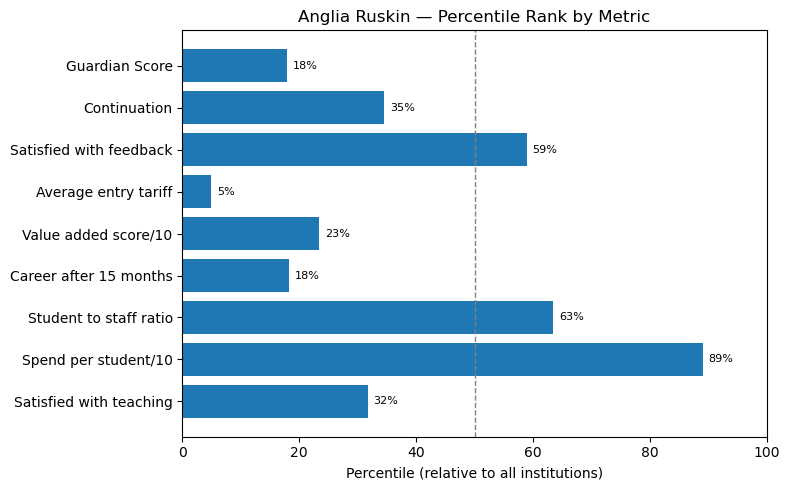

In [21]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

TARGET = "guardianScore"
HIGHLIGHT = "Anglia Ruskin"

cols = df.columns[7:].to_list() + [TARGET]
labels = metrics_labels + ["Guardian Score"]

percentiles = []
for col in cols:
    vals = pd.to_numeric(df[col], errors="coerce")
    aru_val = pd.to_numeric(df.loc[df["name"] == HIGHLIGHT, col], errors="coerce").values[0]
    pct = stats.percentileofscore(vals.dropna(), aru_val)
    percentiles.append(pct)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(labels, percentiles, color="tab:blue")
ax.axvline(50, color="gray", linestyle="--", linewidth=1)  # median reference line
ax.set_xlabel("Percentile (relative to all institutions)")
ax.set_xlim(0, 100)
ax.set_title(f"{HIGHLIGHT} — Percentile Rank by Metric")

for bar, pct in zip(bars, percentiles):
    ax.text(pct + 1, bar.get_y() + bar.get_height()/2, f"{pct:.0f}%", va="center", fontsize=8)

plt.tight_layout()
plt.show()

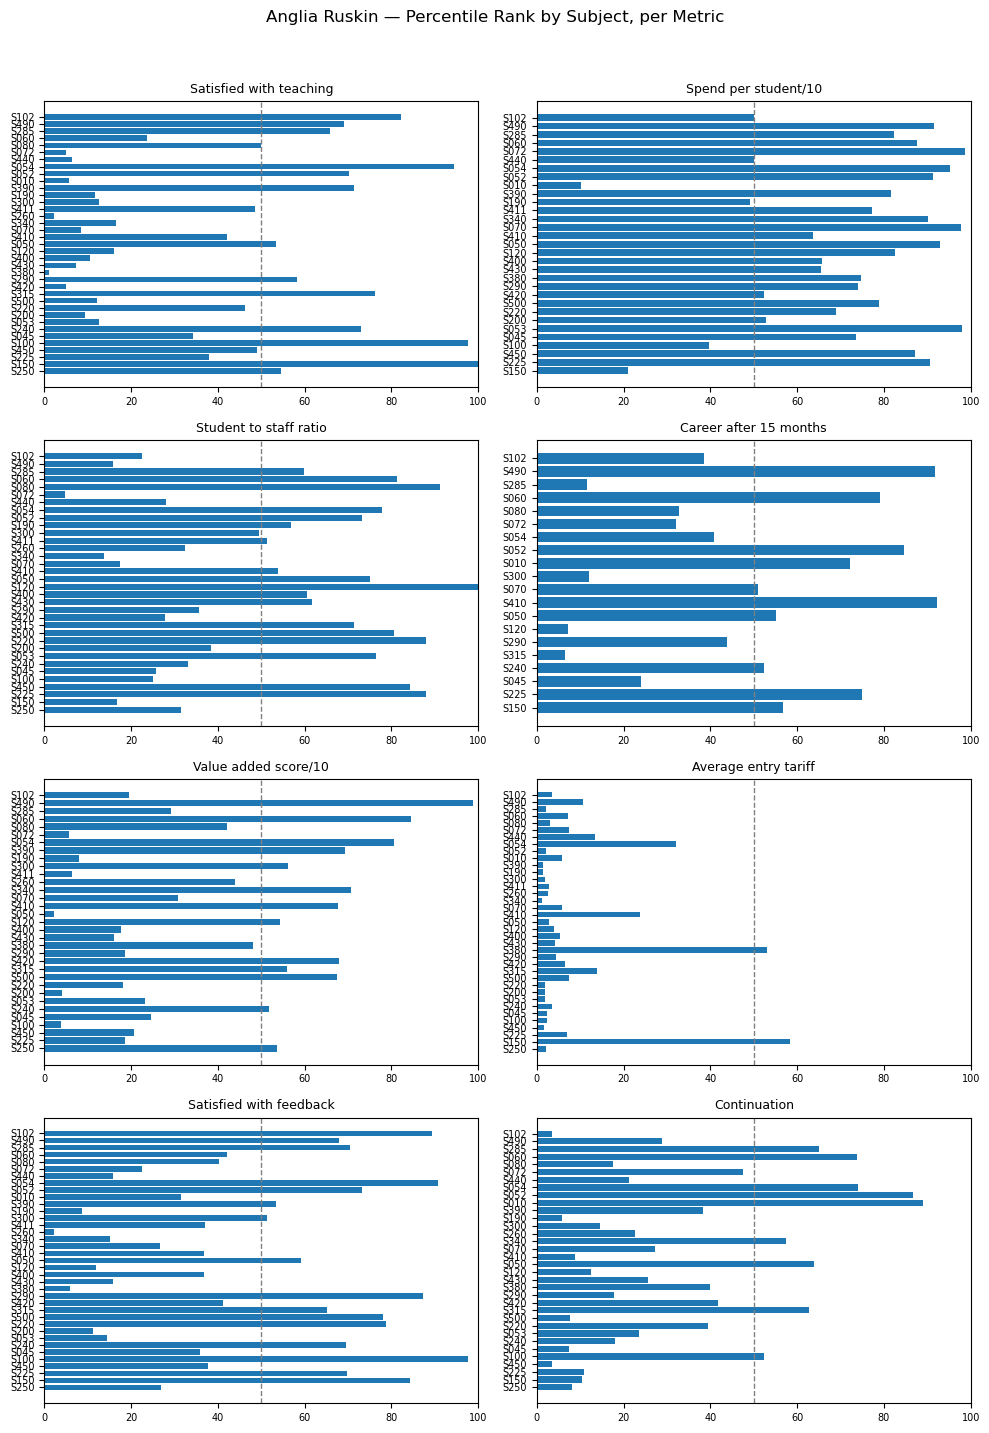

In [22]:
TARGET = "guardianScore"
HIGHLIGHT = "Anglia Ruskin"

metrics = list(dfs.values())[0].columns[6:14].to_list()

fig, axes = plt.subplots(4, 2, figsize=(10, 14))

for ax, col, label in zip(axes.flat, metrics, metrics_labels):

    subjects, pcts = [], []
    for subject, d in dfs.items():
        vals = pd.to_numeric(d[col], errors="coerce").dropna()
        aru_val = pd.to_numeric(d.loc[d["name"] == HIGHLIGHT, col], errors="coerce")
        if aru_val.empty or aru_val.isna().all():
            continue
        pct = stats.percentileofscore(vals, aru_val.values[0])
        subjects.append(subject)
        pcts.append(pct)

    ax.barh(subjects, pcts, color="tab:blue")
    ax.axvline(50, color="gray", linestyle="--", linewidth=1)
    ax.set_xlim(0, 100)
    ax.set_title(label, fontsize=9)
    ax.tick_params(labelsize=7)

fig.suptitle(f"{HIGHLIGHT} — Percentile Rank by Subject, per Metric", y=1.02)
plt.tight_layout()
plt.show()

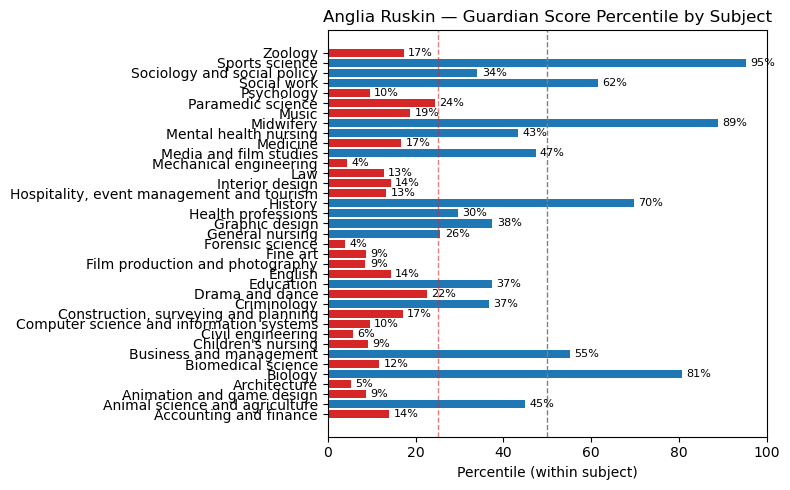

In [23]:
TARGET = "guardianScore"
HIGHLIGHT = "Anglia Ruskin"

subjects, pcts = [], []
for subject_key, d in dfs.items():
    vals = pd.to_numeric(d[TARGET], errors="coerce").dropna()
    aru_row = d.loc[d["name"] == HIGHLIGHT]
    aru_val = pd.to_numeric(aru_row[TARGET], errors="coerce")
    if aru_val.empty or aru_val.isna().all():
        continue
    pct = stats.percentileofscore(vals, aru_val.values[0])
    subject_name = aru_row["subject"].values[0]
    subjects.append(subject_name)
    pcts.append(pct)

colors = ["tab:red" if p < 25 else "tab:blue" for p in pcts]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(subjects, pcts, color=colors)
ax.axvline(25, color="tab:red", linestyle="--", linewidth=1, alpha=0.6)
ax.axvline(50, color="gray", linestyle="--", linewidth=1)
ax.set_xlim(0, 100)
ax.set_xlabel("Percentile (within subject)")
ax.set_title(f"{HIGHLIGHT} — Guardian Score Percentile by Subject")

for bar, pct in zip(bars, pcts):
    ax.text(pct + 1, bar.get_y() + bar.get_height()/2, f"{pct:.0f}%", va="center", fontsize=8)

plt.tight_layout()
plt.show()

### Profile plot

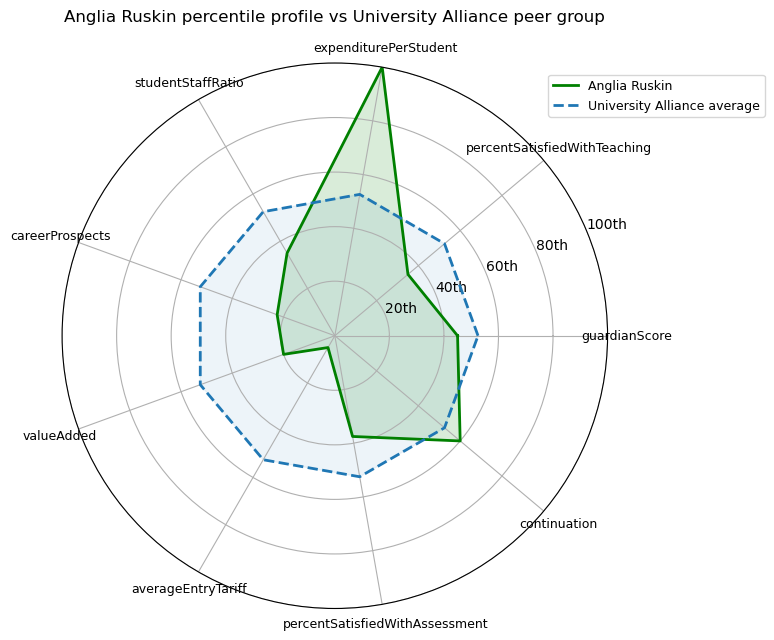

In [24]:
# ---------------------------------------------------------------
# Load data
# ---------------------------------------------------------------
TARGET_INSTITUTION = "Anglia Ruskin"

metrics = ["guardianScore"] + main_rank.columns[7:].to_list()

#metrics = ["Satisfied with teaching",
#                  "Spend per student/10",
#                  "Student to staff ratio",
#                  "Career after 15 months",
#                  "Value added score/10",
#                  "Average entry tariff", 
#                  "Satisfied with feedback",                 
#                  "Continuation"]

# University Alliance member institutions
university_alliance = ua_universities

# ---------------------------------------------------------------
# Filter to peer group and compute percentile rank per metric
# (percentile calculated WITHIN the peer group, not full table)
# ---------------------------------------------------------------
peer_df = df[df["name"].isin(university_alliance)].copy()

for col in metrics:
    peer_df[f"{col}_pct"] = peer_df[col].rank(pct=True) * 100

pct_cols = [f"{c}_pct" for c in metrics]

aru_row = peer_df.loc[peer_df["name"] == TARGET_INSTITUTION, pct_cols].iloc[0]
peer_avg = peer_df[pct_cols].mean()

# ---------------------------------------------------------------
# Radar plot: Anglia Ruskin vs peer group average
# ---------------------------------------------------------------
labels = metrics
n = len(labels)
angles = np.linspace(0, 2 * np.pi, n, endpoint=False).tolist()
angles += angles[:1]  # close the loop

aru_values = aru_row.tolist() + [aru_row.tolist()[0]]
peer_values = peer_avg.tolist() + [peer_avg.tolist()[0]]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

ax.plot(angles, aru_values, color="green", linewidth=2, label="Anglia Ruskin")
ax.fill(angles, aru_values, color="green", alpha=0.15)

ax.plot(angles, peer_values, color="tab:blue", linewidth=2, linestyle="--",
        label="University Alliance average")
ax.fill(angles, peer_values, color="tab:blue", alpha=0.08)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylim(0, 100)
ax.set_yticks([20, 40, 60, 80, 100])
ax.set_yticklabels(["20th", "40th", "60th", "80th", "100th"], fontsize=10)
ax.set_title("Anglia Ruskin percentile profile vs University Alliance peer group",
             fontsize=12, pad=30)
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 0.99), fontsize=9)

plt.tight_layout()
plt.show()

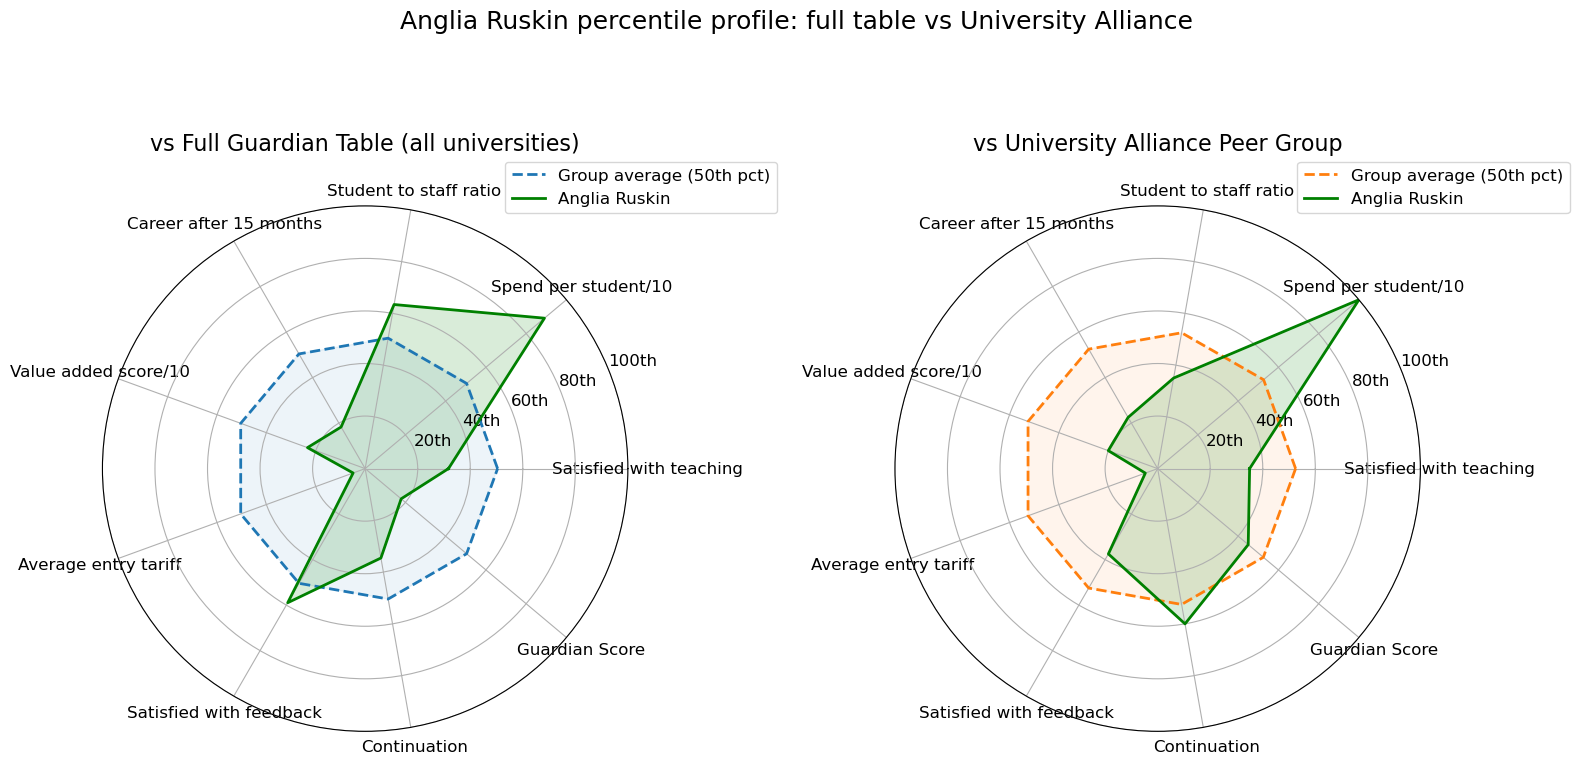

In [75]:
# ---------------------------------------------------------------
# Load data
# ---------------------------------------------------------------
TARGET_INSTITUTION = "Anglia Ruskin"
TARGET = "guardianScore"

metrics = main_rank.columns[7:].to_list()

# Include Guardian Score itself as one of the radar axes
all_cols = metrics + [TARGET]

# University Alliance member institutions
university_alliance = ua_universities

# ---------------------------------------------------------------
# Helper: compute ARU + peer-group-average percentiles for a
# given subset of the data
# ---------------------------------------------------------------
def compute_profile(data, cols, target_institution):
    work = data.copy()
    pct_cols = []
    for col in cols:
        pct_col = f"{col}_pct"
        work[pct_col] = work[col].rank(pct=True) * 100
        pct_cols.append(pct_col)

    aru_row = work.loc[work["name"] == target_institution, pct_cols].iloc[0]
    group_avg = work[pct_cols].mean()
    return aru_row.tolist(), group_avg.tolist()

full_aru, full_avg = compute_profile(df, all_cols, TARGET_INSTITUTION)

ua_df = df[df["name"].isin(university_alliance)].copy()
ua_aru, ua_avg = compute_profile(ua_df, all_cols, TARGET_INSTITUTION)

# ---------------------------------------------------------------
# Radar setup
# ---------------------------------------------------------------
labels = metrics_labels + ["Guardian Score"]
n = len(labels)
angles = np.linspace(0, 2 * np.pi, n, endpoint=False).tolist()
angles += angles[:1]

def close_loop(values):
    return values + [values[0]]

fig, axes = plt.subplots(1, 2, figsize=(16, 8), subplot_kw=dict(polar=True))

panel_data = [
    (axes[0], full_aru, full_avg, "vs Full Guardian Table (all universities)", "tab:blue"),
    (axes[1], ua_aru, ua_avg, "vs University Alliance Peer Group", "tab:orange"),
]

for ax, aru_vals, avg_vals, title, avg_color in panel_data:
    aru_closed = close_loop(aru_vals)
    avg_closed = close_loop(avg_vals)

    ax.plot(angles, avg_closed, color=avg_color, linewidth=2, linestyle="--",
            label="Group average (50th pct)")
    ax.fill(angles, avg_closed, color=avg_color, alpha=0.08)

    ax.plot(angles, aru_closed, color="green", linewidth=2, label="Anglia Ruskin")
    ax.fill(angles, aru_closed, color="green", alpha=0.15)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels, fontsize=12)
    ax.set_ylim(0, 100)
    ax.set_yticks([20, 40, 60, 80, 100])
    ax.set_yticklabels(["20th", "40th", "60th", "80th", "100th"], fontsize=12)
    ax.set_title(title, fontsize=16, pad=40)
    ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1), fontsize=12)

fig.suptitle("Anglia Ruskin percentile profile: full table vs University Alliance",
             fontsize=18, y=1.02)
plt.tight_layout()
plt.show()

### Percentile Heatmaps

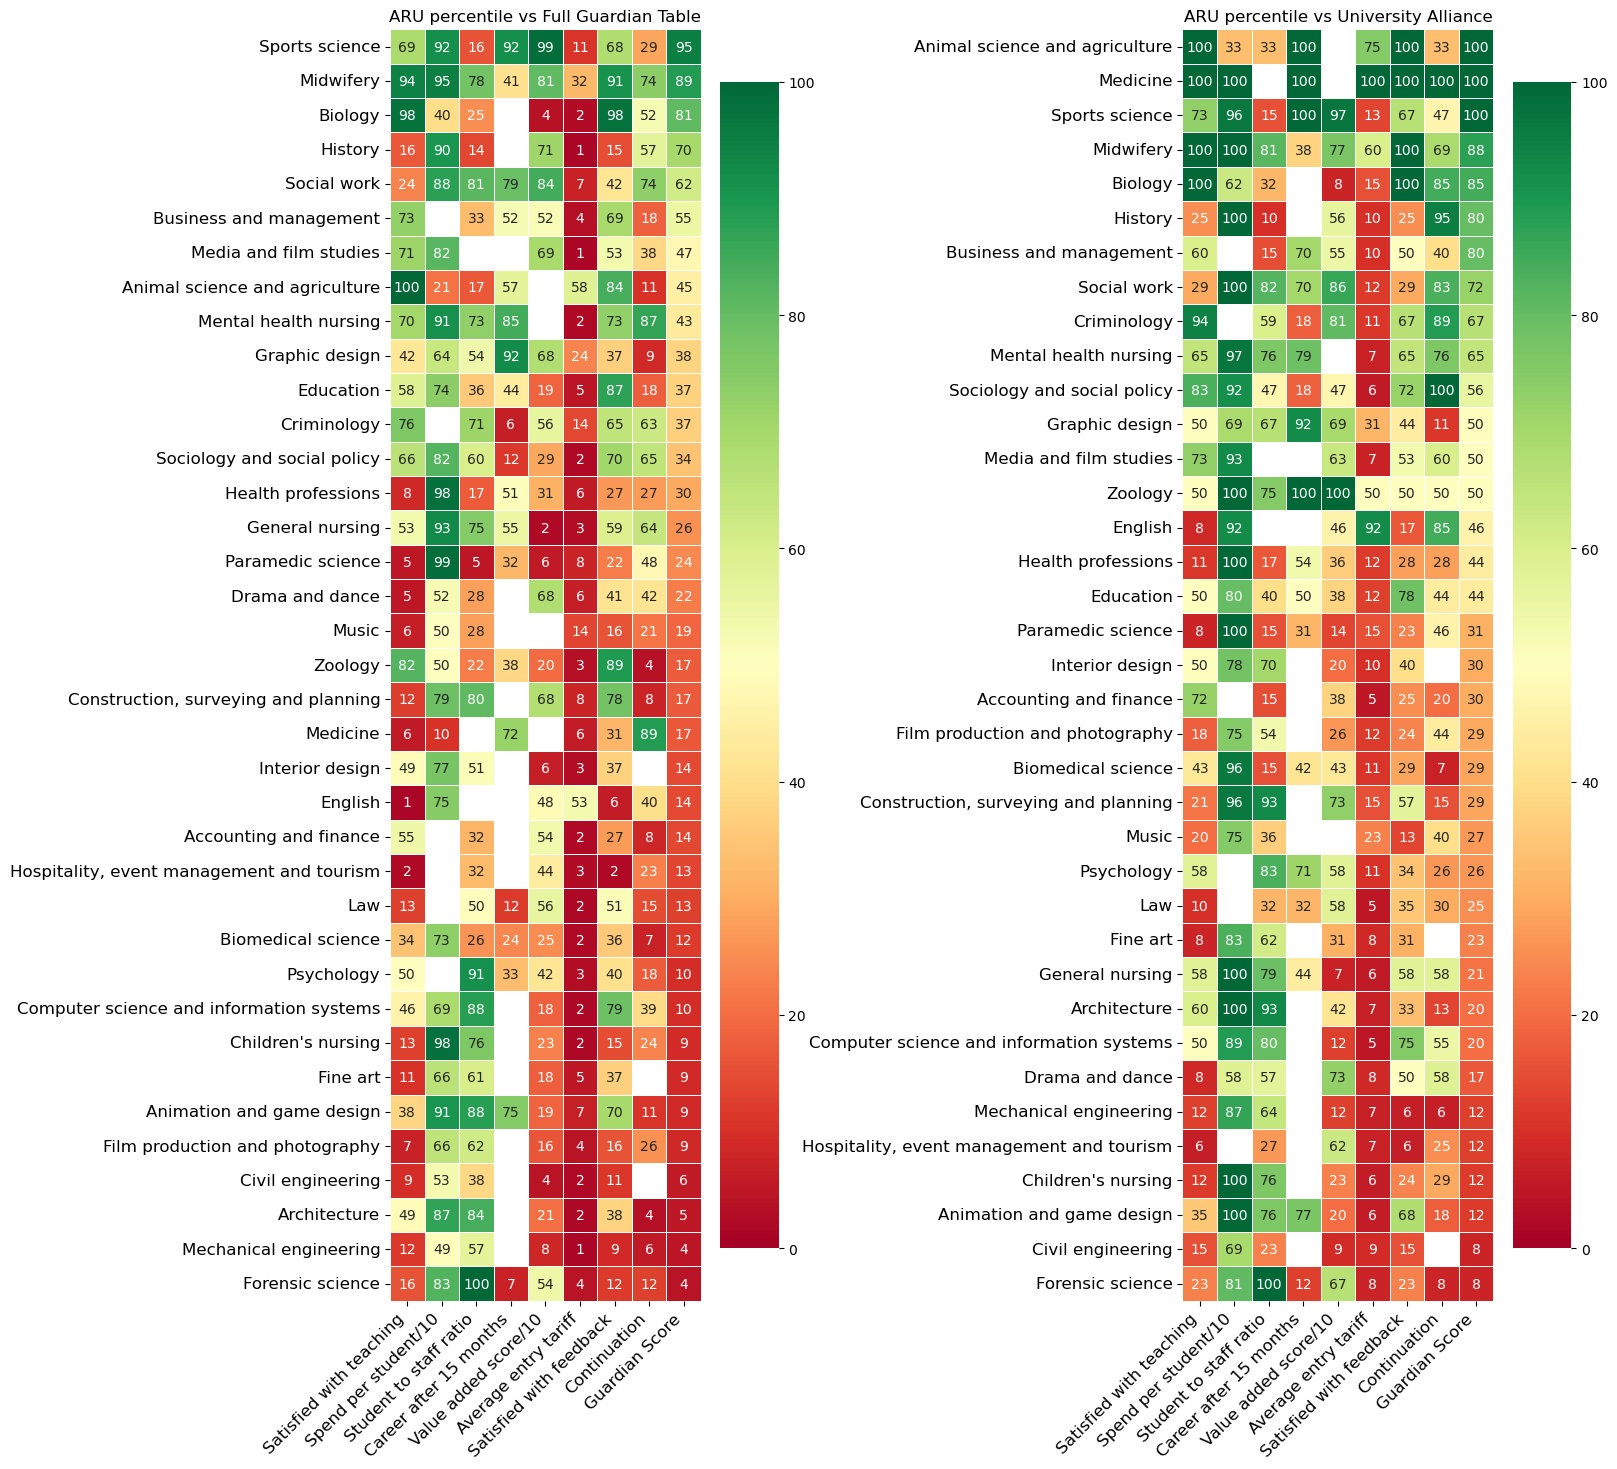

In [83]:
TARGET_INSTITUTION = "Anglia Ruskin"
TARGET = "guardianScore"
labels = metrics_labels + ["Guardian Score"]

# ---------------------------------------------------------------
# Build ARU percentile matrix (subjects x metrics)
# ---------------------------------------------------------------
def build_percentile_matrix(tables, cols, target, group=None):
    rows = {}
    for subject, sdf in tables.items():
        data = sdf[sdf["name"].isin(group)] if group else sdf
        if target not in data["name"].values:
            continue
        subject = data["subject"].iloc[0]
        row = {}
        for col in cols:
            row[col] = pd.to_numeric(data[col], errors="coerce").rank(pct=True)[data["name"] == target].iloc[0] * 100
        rows[subject] = row
    return pd.DataFrame(rows).T

matrix_ua = build_percentile_matrix(subject_dataframes, metrics + [TARGET], TARGET_INSTITUTION,
                                     group=university_alliance)
matrix_all = build_percentile_matrix(subject_dataframes, metrics + [TARGET], TARGET_INSTITUTION)

matrix_all = matrix_all.sort_values(by=matrix_all.columns[-1], ascending=False)
matrix_ua = matrix_ua.sort_values(by=matrix_ua.columns[-1], ascending=False)

# ---------------------------------------------------------------
# Plot
# ---------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, max(6, 0.4 * len(matrix_all))))

sns.heatmap(matrix_all, annot=True, fmt=".0f", cmap="RdYlGn", vmin=0, vmax=100,
            linewidths=0.5, ax=axes[0])
axes[0].set_title("ARU percentile vs Full Guardian Table")

sns.heatmap(matrix_ua, annot=True, fmt=".0f", cmap="RdYlGn", vmin=0, vmax=100,
            linewidths=0.5, ax=axes[1])
axes[1].set_title("ARU percentile vs University Alliance")
axes[1].set_ylabel("")

axes[0].set_xticks(np.arange(len(labels)) + 0.5)
axes[0].set_xticklabels(labels, rotation=45, ha="right", fontsize=12)
axes[0].set_yticks(np.arange(len(matrix_all)) + 0.5)
axes[0].set_yticklabels(matrix_all.index.tolist(), rotation=0, fontsize=12)

axes[1].set_xticks(np.arange(len(labels)) + 0.5)
axes[1].set_xticklabels(labels, rotation=45, ha="right", fontsize=12)
axes[1].set_yticks(np.arange(len(matrix_ua)) + 0.5)
axes[1].set_yticklabels(matrix_ua.index.tolist(), rotation=0, fontsize=12)

plt.tight_layout()
plt.show()